In [4]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [5]:
import os

In [6]:
os.getcwd()

'C:\\Users\\Dell'

In [7]:
superstore=pd.read_csv('C:\\Users\\Dell\\Downloads\\superstore.csv')

In [8]:
df=superstore

In [9]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08-11-2017,11-11-2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08-11-2017,11-11-2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12-06-2017,16-06-2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11-10-2016,18-10-2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11-10-2016,18-10-2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [11]:
df.shape

(9800, 18)

In [12]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

In [13]:
for col in df.columns:
    print(col)

Row ID
Order ID
Order Date
Ship Date
Ship Mode
Customer ID
Customer Name
Segment
Country
City
State
Postal Code
Region
Product ID
Category
Sub-Category
Product Name
Sales


In [14]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [15]:
df['Postal Code']=df['Postal Code'].fillna(df['Postal Code'].mode()[0])

In [16]:
df['Order Date']=pd.to_datetime(df['Order Date'],dayfirst=True)

In [17]:
df['Ship Date']=pd.to_datetime(df['Ship Date'],dayfirst=True)

In [18]:
df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales
count,9800.000000,9800,9800,9800.000000,9800.000000
mean,4900.500000,2017-05-01 05:13:51.673469440,2017-05-05 04:17:52.653061120,55222.544694,230.769059
min,1.000000,2015-01-03 00:00:00,2015-01-07 00:00:00,1040.000000,0.444000
25%,2450.750000,2016-05-24 00:00:00,2016-05-27 18:00:00,23223.000000,17.248000
50%,4900.500000,2017-06-26 00:00:00,2017-06-29 00:00:00,57551.000000,54.490000
75%,7350.250000,2018-05-15 00:00:00,2018-05-19 00:00:00,90008.000000,210.605000
max,9800.000000,2018-12-30 00:00:00,2019-01-05 00:00:00,99301.000000,22638.480000
std,2829.160653,NaN,NaN,32059.043706,626.651875


In [19]:
df.groupby('Category')['Sales'].sum().sort_values(ascending=False).round(0).astype(int)

Category
Technology         827456
Furniture          728659
Office Supplies    705422
Name: Sales, dtype: int64

In [20]:
sales_by_category = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)


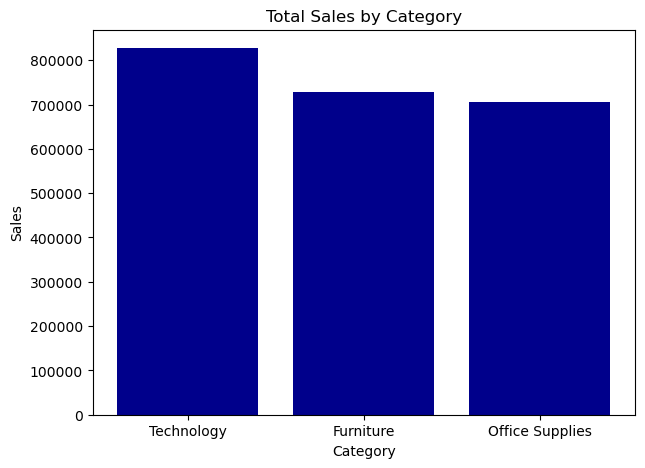

In [21]:
plt.figure(figsize=(7,5))
plt.bar(sales_by_category.index, sales_by_category.values, color='darkblue')
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Sales')
plt.show()

In [22]:
region_sales=df.groupby('Region')['Sales'].sum().sort_values(ascending=False).round(0).astype(int)

In [23]:
region_sales

Region
West       710220
East       669519
Central    492647
South      389151
Name: Sales, dtype: int64

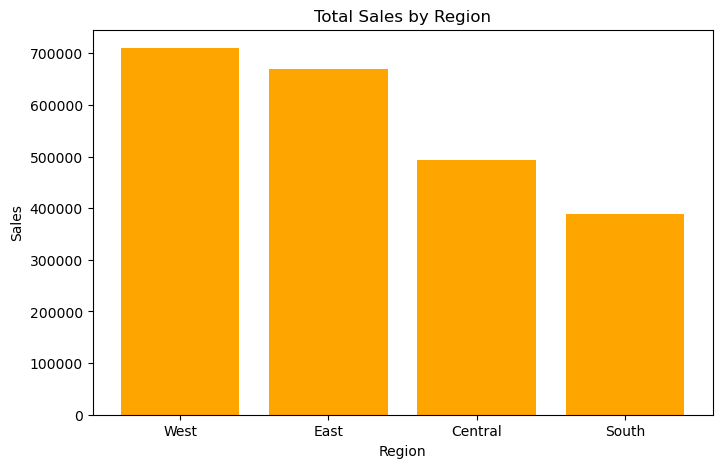

In [24]:
plt.figure(figsize=(8,5))
plt.bar(region_sales.index,region_sales.values,color='orange')
plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Sales')
plt.show()


In [25]:
monthly_sales = df.groupby(df['Order Date'].dt.strftime('%b'))['Sales'].sum().round(0).astype(int)

monthly_sales = monthly_sales.reindex(
['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
)


In [26]:
monthly_sales

Order Date
Jan     94292
Feb     59371
Mar    197574
Apr    136283
May    154087
Jun    145838
Jul    145536
Aug    157316
Sep    300103
Oct    199496
Nov    350162
Dec    321480
Name: Sales, dtype: int64

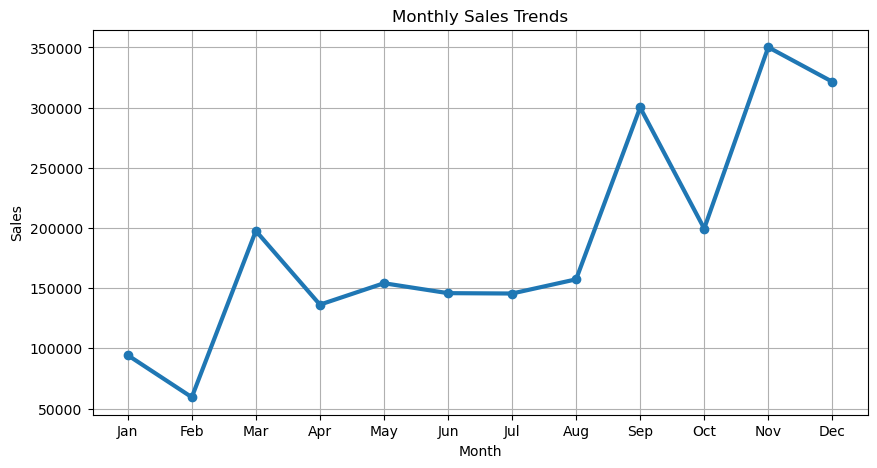

In [27]:
plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index,monthly_sales.values,marker='o',linewidth=3)
plt.title('Monthly Sales Trends')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.grid(True)
plt.show()

In [28]:
state_sales=df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10).round(0).astype(int)

In [29]:
state_sales

State
California      446306
New York        306361
Texas           168573
Washington      135207
Pennsylvania    116277
Florida          88437
Illinois         79237
Michigan         76136
Ohio             75130
Virginia         70637
Name: Sales, dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

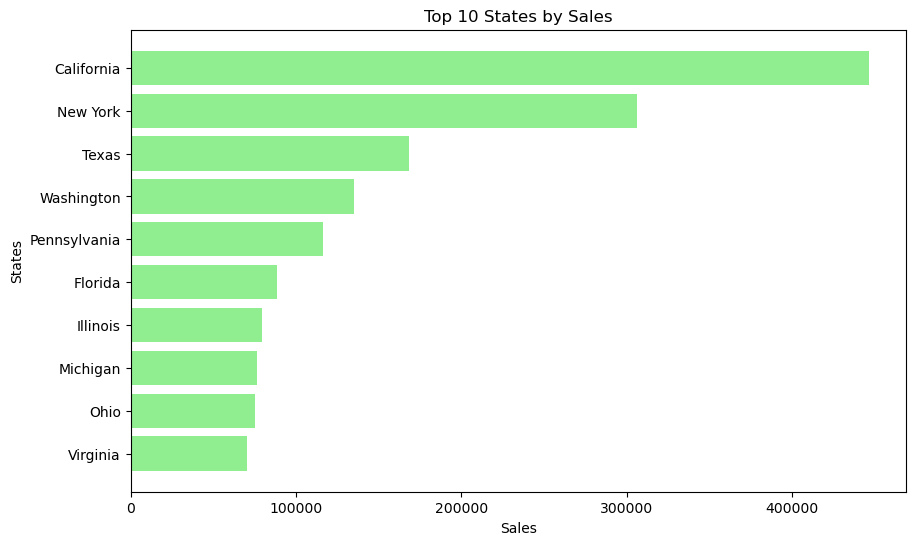

In [30]:
plt.figure(figsize=(10,6))
plt.barh(state_sales.index,state_sales.values,color='lightgreen')
plt.title('Top 10 States by Sales')
plt.xlabel('Sales')
plt.ylabel('States')
plt.gca().invert_yaxis()
plt.show

In [31]:
sub_categories=df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).round(0).astype(int)

In [32]:
sub_categories

Sub-Category
Phones         327782
Chairs         322823
Storage        219343
Tables         202811
Binders        200029
Machines       189239
Accessories    164187
Copiers        146248
Bookcases      113813
Appliances     104618
Furnishings     89212
Paper           76828
Supplies        46420
Art             26705
Envelopes       16128
Labels          12348
Fasteners        3002
Name: Sales, dtype: int64

In [33]:
top10_sub=sub_categories.head(10)

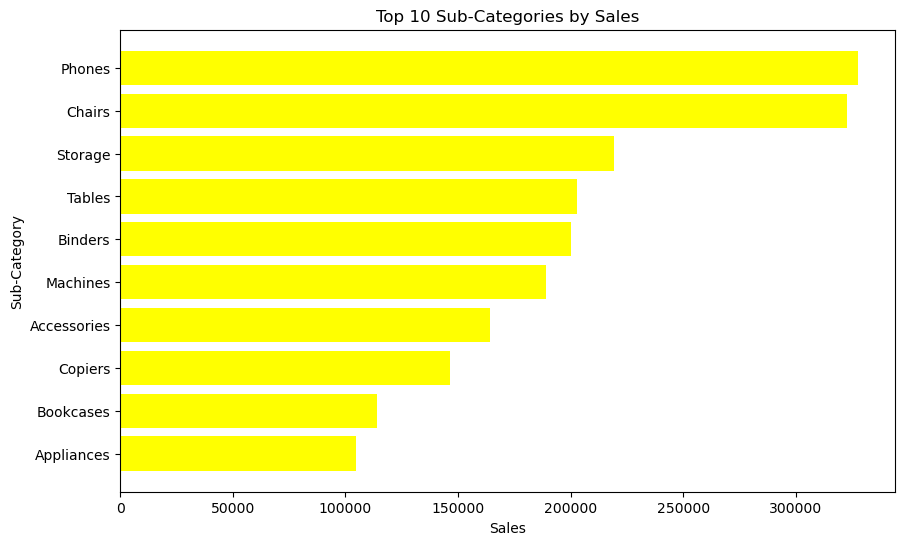

In [34]:
plt.figure(figsize=(10,6))
plt.barh(top10_sub.index,top10_sub.values,color='yellow')
plt.title('Top 10 Sub-Categories by Sales')
plt.xlabel('Sales')
plt.ylabel('Sub-Category')
plt.gca().invert_yaxis()
plt.show()

In [35]:
segment_sales=df.groupby('Segment')['Sales'].sum().sort_values(ascending=False).round(0).astype(int)

In [36]:
segment_sales

Segment
Consumer       1148061
Corporate       688494
Home Office     424982
Name: Sales, dtype: int64

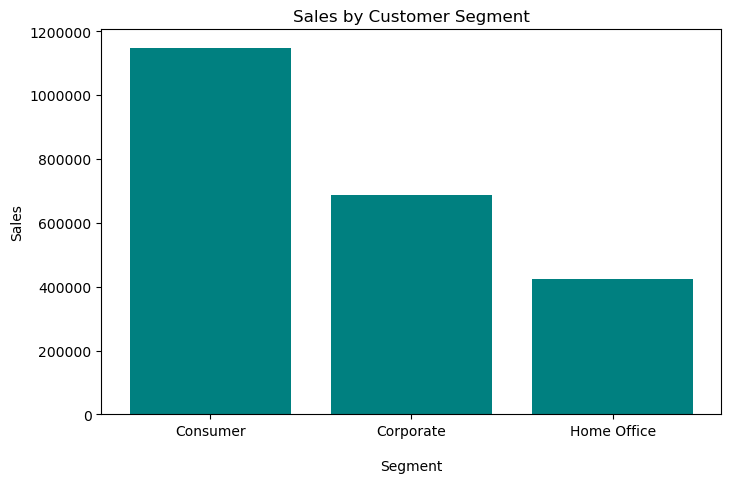

In [37]:
plt.figure(figsize=(8,5))
plt.bar(segment_sales.index,segment_sales.values,color='teal')
plt.title('Sales by Customer Segment')
plt.xlabel('Segment',labelpad=15)
plt.ylabel('Sales')
plt.ticklabel_format(style='plain', axis='y')
plt.show()

In [38]:
ship_sales=df.groupby('Ship Mode')['Sales'].sum().sort_values(ascending=False).round(0).astype(int)

In [39]:
ship_sales

Ship Mode
Standard Class    1340831
Second Class       449914
First Class        345572
Same Day           125219
Name: Sales, dtype: int64

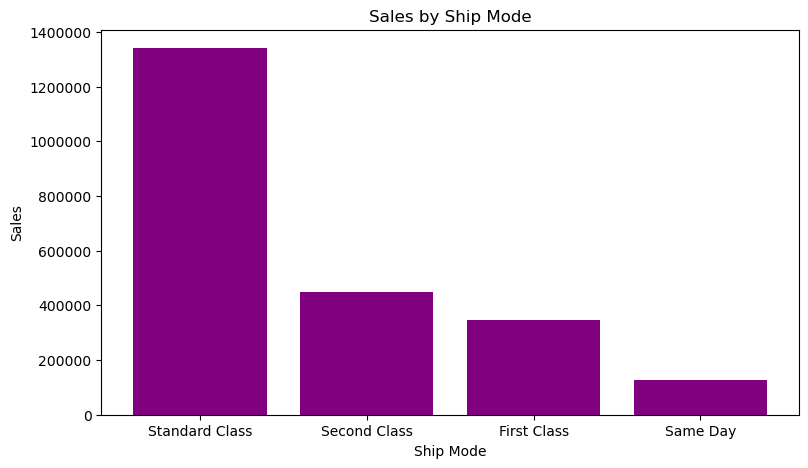

In [40]:
plt.figure(figsize=(9,5))
plt.bar(ship_sales.index, ship_sales.values, color='purple')
plt.title('Sales by Ship Mode')
plt.xlabel('Ship Mode')
plt.ylabel('Sales')
plt.ticklabel_format(style='plain', axis='y')
plt.show()

In [41]:
top_customers=df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10).round(0).astype(int)

In [42]:
top_customers

Customer Name
Sean Miller           25043
Tamara Chand          19052
Raymond Buch          15117
Tom Ashbrook          14596
Adrian Barton         14474
Ken Lonsdale          14175
Sanjit Chand          14142
Hunter Lopez          12873
Sanjit Engle          12209
Christopher Conant    12129
Name: Sales, dtype: int64

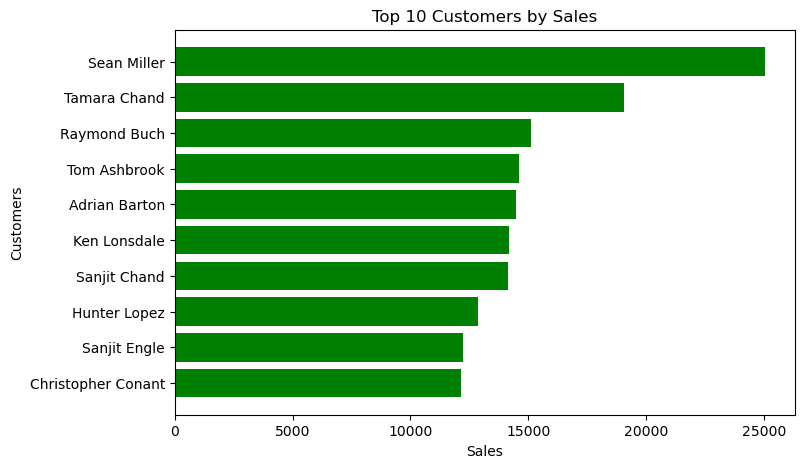

In [43]:
plt.figure(figsize=(8,5))
plt.barh(top_customers.index,top_customers.values,color='green')
plt.title('Top 10 Customers by Sales')
plt.xlabel('Sales')
plt.ylabel('Customers')
plt.gca().invert_yaxis()
plt.show()

In [44]:
top_cities = df.groupby('City')['Sales'].sum().sort_values(ascending=False).head(10).round(0).astype(int)

In [45]:
top_cities

City
New York City    252463
Los Angeles      173420
Seattle          116106
San Francisco    109041
Philadelphia     108842
Houston           63956
Chicago           47820
San Diego         47521
Jacksonville      44713
Detroit           42447
Name: Sales, dtype: int64

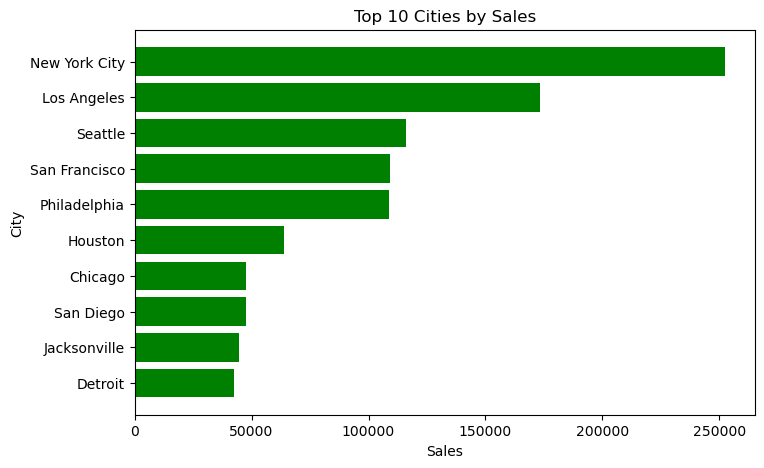

In [46]:
plt.figure(figsize=(8,5))
plt.barh(top_cities.index,top_cities.values,color='green')
plt.title('Top 10 Cities by Sales')
plt.xlabel('Sales')
plt.ylabel('City')
plt.gca().invert_yaxis()
plt.show()

In [47]:
df['Delivery Days'] = (df['Ship Date'] - df['Order Date']).dt.days

In [48]:
round(df['Delivery Days'].mean())

4

In [49]:
df = superstore
df.to_csv("cleaned_superstore.csv", index=False)
print("Cleaned data saved")

Cleaned data saved


In [50]:
import os
os.getcwd()

'C:\\Users\\Dell'